## Treinando uma Rede Neural Convolucional usando o Keras

- Arquitetura simples com duas camadas convolucionais
- Utilizando um conjunto de imagens de células cervicais

## Base de imagens de células cervicais
#### Células anormais
![](abnormal.png "Abnormal Cell")
#### Células normais
![alt text](normal.png "Normal Cell")


# Imports

In [61]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from glob import glob
from skimage.io import imread
from skimage.transform import resize

# Ler dados

In [62]:
database_classes = glob('database/*/')
n_classes = len(database_classes)
n_files = glob('database/*/*.tif')

labels = np.zeros((len(n_files),n_classes))
images = np.zeros((len(n_files),100,100,3))

cont = 0
lb = 0
for classes in database_classes:
    files_in_classe = glob(classes+'*.tif')
    for fc in files_in_classe:
        labels[cont,lb] = 1
        im = imread(fc)
        image_resized = resize(im, (100,100,3))
        images[cont,:,:,:] = image_resized
        cont+=1
    lb +=1

In [63]:
labels.shape

(200, 2)

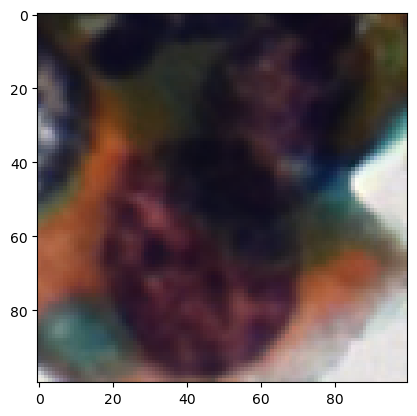

In [64]:
plt.imshow(images[2,:,:,:])

# Dividindo dados em Treino e Teste

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(images, labels, test_size = 0.2)

In [66]:
print('Tamanho do Treino: ', X_train.shape)
print('Tamanho do Teste: ', X_test.shape)

Tamanho do Treino:  (160, 100, 100, 3)
Tamanho do Teste:  (40, 100, 100, 3)


# Construindo a CNN

In [67]:
import keras
import keras.layers as layers
from keras.models import Sequential
from keras.preprocessing.image import ImageDataGenerator
from keras.utils.np_utils import to_categorical
from keras.callbacks import TensorBoard
from time import time

In [68]:
model = keras.Sequential()

model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(100,100,3),name='layer_conv1'))
model.add(layers.MaxPool2D(pool_size=(2, 2),name='layer_pool1'))

model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu',name='layer_conv2'))
model.add(layers.MaxPool2D(pool_size=(2, 2),name='layer_pool2'))

#model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu',name='layer_conv3'))
#model.add(layers.MaxPool2D(pool_size=(2, 2),name='layer_pool3'))


model.add(layers.Flatten(name='layer_flatten'))

model.add(layers.Dropout(rate=0.75,name='layer_drop'))

model.add(layers.Dense(units=256, activation='relu',name='layer_fc1'))

model.add(layers.Dense(units=128, activation='relu',name='layer_fc2'))

model.add(layers.Dense(units=2, activation = 'softmax',name='layer_softmax'))

In [69]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer_conv1 (Conv2D)        (None, 98, 98, 64)        1792      
                                                                 
 layer_pool1 (MaxPooling2D)  (None, 49, 49, 64)        0         
                                                                 
 layer_conv2 (Conv2D)        (None, 47, 47, 64)        36928     
                                                                 
 layer_pool2 (MaxPooling2D)  (None, 23, 23, 64)        0         
                                                                 
 layer_flatten (Flatten)     (None, 33856)             0         
                                                                 
 layer_drop (Dropout)        (None, 33856)             0         
                                                                 
 layer_fc1 (Dense)           (None, 256)              

In [70]:
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.SGD(0.01), metrics=['accuracy'])

In [71]:
EPOCHS = 150
BATCH_SIZE = 64

In [72]:
X_train, X_validation, Y_train, Y_validation = train_test_split(X_train, Y_train, test_size = 0.2)
train_generator = ImageDataGenerator().flow(X_train, Y_train, batch_size=BATCH_SIZE)
validation_generator = ImageDataGenerator().flow(X_validation, Y_validation, batch_size=BATCH_SIZE)

In [73]:
steps_per_epoch = X_train.shape[0]//BATCH_SIZE
validation_steps = X_validation.shape[0]//BATCH_SIZE

tensorboard = TensorBoard(log_dir="logs/{}".format(time()))
model.fit_generator(train_generator, steps_per_epoch=steps_per_epoch, epochs=EPOCHS, 
                    validation_data=validation_generator, validation_steps=validation_steps, 
                    shuffle=True, callbacks=[tensorboard])

Epoch 1/150


/var/folders/29/5dv_l5l530z1h9r5814wdc0r0000gn/T/ipykernel_37710/3863351427.py:5: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(train_generator, steps_per_epoch=steps_per_epoch, epochs=EPOCHS,
2026-04-25 11:57:13.238333: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


2/2 [==============================] - 1s 186ms/step - loss: 0.6943 - accuracy: 0.5156
Epoch 2/150
1/2 [==============>...............] - ETA: 0s - loss: 0.6917 - accuracy: 0.4688

2026-04-25 11:57:13.864400: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


2/2 [==============================] - 0s 178ms/step - loss: 0.6730 - accuracy: 0.5000
Epoch 3/150
2/2 [==============================] - 0s 172ms/step - loss: 0.6408 - accuracy: 0.5312
Epoch 4/150
2/2 [==============================] - 0s 183ms/step - loss: 0.6519 - accuracy: 0.5391
Epoch 5/150
2/2 [==============================] - 0s 172ms/step - loss: 0.6367 - accuracy: 0.5391
Epoch 6/150
2/2 [==============================] - 0s 170ms/step - loss: 0.6317 - accuracy: 0.5859
Epoch 7/150
2/2 [==============================] - 0s 166ms/step - loss: 0.6499 - accuracy: 0.6172
Epoch 8/150
2/2 [==============================] - 0s 169ms/step - loss: 0.6287 - accuracy: 0.5547
Epoch 9/150
2/2 [==============================] - 0s 167ms/step - loss: 0.6225 - accuracy: 0.5859
Epoch 10/150
2/2 [==============================] - 0s 166ms/step - loss: 0.6040 - accuracy: 0.6406
Epoch 11/150
2/2 [==============================] - 0s 176ms/step - loss: 0.5908 - accuracy: 0.6719
Epoch 12/150
2/2 [==

In [74]:
score = model.evaluate(X_test, Y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 [==============================] - 0s 10ms/step - loss: 0.1327 - accuracy: 0.9250
Test loss: 0.1326896697282791
Test accuracy: 0.925000011920929


# Atividades

### Pesquisar o uso de redes pré-treinadas no Keras
### Pesquisar o uso de fine-tuning no Keras
### Pesquisar o uso da rede U-Net no Keras

## Enviar um notebook com exemplo de utilização dessas 3 técnicas até 03/09/2020.